    Xác định đối tượng trong ảnh
-	Viết được chương trình gán nhãn cho phân vùng ảnh
-	Viết được chương trình phân vùng ảnh theo Region
-	Viết được chương trình thay đổi ảnh


In [13]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

import cv2
from skimage.color import rgb2gray
from skimage.feature import corner_harris


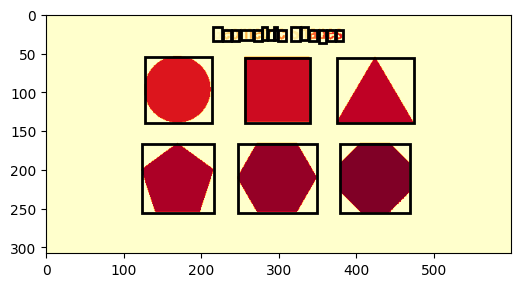

In [8]:
#chương trình gắn nhãn ảnh
data = Image.open('exercise/geometric.png').convert('L')
a = np.asanyarray(data)
thres = threshold_otsu(a)
b=a>thres
c=label(b)
c1=Image.fromarray(c)
iio.imsave('exercise/lable_output.png',c1)

properties = ['Area', 'Centroid', 'BoundingBox']
d = regionprops(c)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6,6))
ax.imshow(c,cmap='YlOrRd')

for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rec_width = uc-lc
    rec_height = ur-lr
    rect = mpatches.Rectangle((lc,lr),rec_width,rec_height, fill=False,
                              edgecolor = 'black', linewidth=2)
    ax.add_patch(rect)
plt.show()

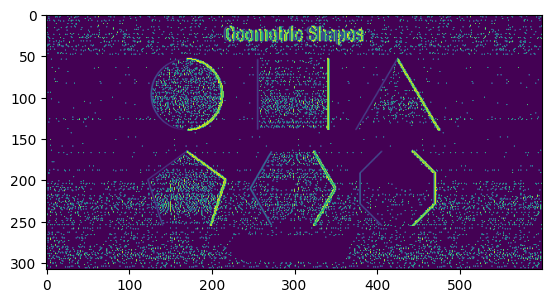

In [9]:
#2.2  Dò tìm cạnh theo chiều dọc
data = Image.open('exercise/geometric.png').convert('L')
bmg = abs(data-nd.shift(data,(0,1),order=0))
plt.imshow(bmg)
plt.show()

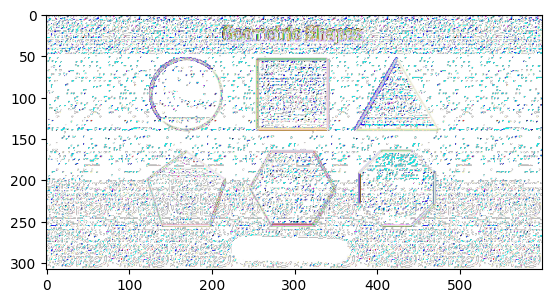

In [10]:
#2.3 dò tìm cạnh với sobel filter
data = Image.open('exercise/geometric.png')
a = nd.sobel(data, axis=0)
b = nd.sobel(data, axis=1)
bmg = abs(a) + abs(b)
plt.imshow(bmg)
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


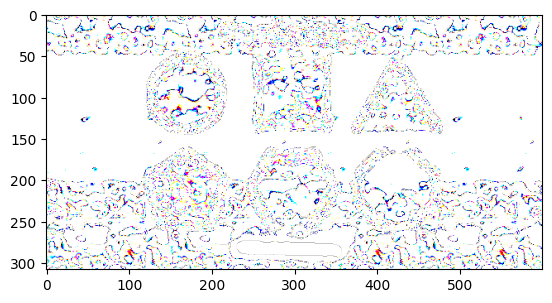

In [12]:
#2.4 xác điinh góc của đối tượng
def Harris(indata, alpha=0.2):
    x = nd.sobel(indata,0)
    y = nd.sobel(indata,1)
    x1 = x ** 2
    y1 = y ** 2
    xy =  abs(x*y)
    x1 = nd.gaussian_filter(x1,3)
    y1 = nd.gaussian_filter(y1,3)
    xy = nd.gaussian_filter(xy,3)

    detC = x1 * y1 - 2 * xy
    trC = x1 + y1
    R = detC -alpha * trC**2
    return R


data = Image.open('exercise/geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()

In [ ]:
#2.5 dò tìm hình dạng cụ thể trong ảnh với Hough Transfrom
#2.5.1 dò tìm đường thẳng trong ảnh


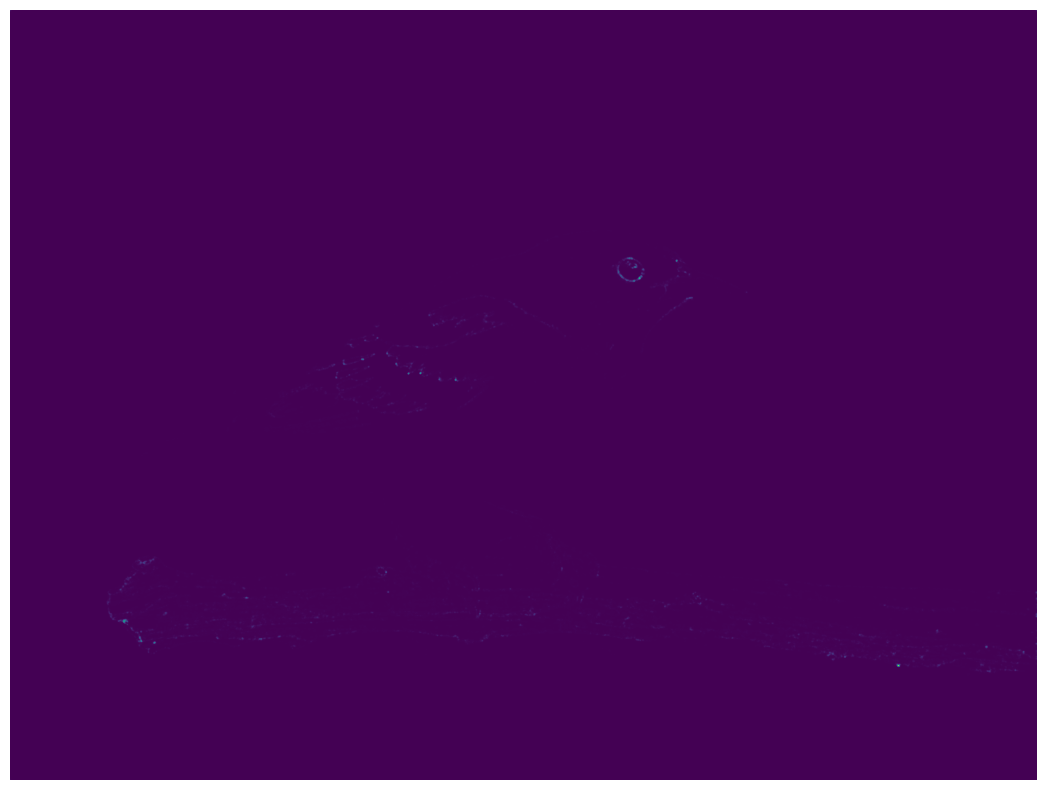

In [14]:
#2.5.2 dò tìm đường tròn trong ảnh
data = Image.open('exercise/bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k=0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()

In [ ]:
#2.6 Image matching
